# Corn Trait Introgression Calculator Tutorial

**A comprehensive guide to calculating population sizes and backcross generations for maize breeding programs**

**Author: Jingyu JP Peng**



---

## Table of Contents

1. [Introduction to Trait Introgression](#section1)
2. [Maize Genome Parameters](#section2)
3. [Expected RP Recovery (Theory)](#section3)
4. [Variance of RP Recovery](#section4)
5. [Population Size for Backcross Generations (BCnF1)](#section5)
6. [Population Size for Selfing Generations (BCnF2)](#section6)
7. [Minimum Backcross Generations](#section7)
8. [Complete Workflow Example](#section8)
9. [Interactive Parameter Explorer](#section9)
10. [Sensitivity Analysis](#section10)
11. [Assumptions and Limitations](#section11)
12. [Exercises](#section12)

## Setup: Import Required Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown
import ipywidgets as widgets
from IPython.display import display, Markdown, HTML
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


<a id='section1'></a>
# Section 1: Introduction to Trait Introgression

## What is Trait Introgression?

**Trait introgression** (also called **backcross breeding**) is a breeding method used to transfer one or more desirable traits from a **Donor Parent (DP)** into an elite **Recurrent Parent (RP)** while recovering the RP's genetic background.

### Why Use Trait Introgression?

- Transfer specific traits (disease resistance, drought tolerance, etc.) from exotic or wild germplasm
- Maintain the elite performance of the recurrent parent
- Create near-isogenic lines (NILs) for genetic studies
- Incorporate transgenic or gene-edited traits into elite backgrounds

### Key Terminology

| Term | Definition |
|------|------------|
| **Donor Parent (DP)** | The parent contributing the trait(s) of interest |
| **Recurrent Parent (RP)** | The elite parent whose genome we want to recover |
| **Backcross (BC)** | Crossing a hybrid back to the recurrent parent |
| **Selfing** | Self-pollinating a plant to fix traits homozygous |
| **Recovery Rate** | Percentage of RP genome in the progeny |
| **F1** | First filial generation (RP × DP) |
| **BCnF1** | nth backcross generation |
| **BCnF2** | Selfed progeny of BCnF1 |

### Breeding Scheme Diagram

The typical trait introgression workflow follows this pattern:

```
Recurrent Parent (RP)  ×  Donor Parent (DP)
         │                      │
         └──────────┬──────────┘
                    ▼
                   F1 (50% RP genome)
                    │
                    × RP (backcross)
                    ▼
                 BC1F1 (75% RP genome expected)
                    │
                    × RP (backcross)
                    ▼
                 BC2F1 (87.5% RP genome expected)
                    │
                    × RP (backcross)
                    ▼
                 BC3F1 (93.75% RP genome expected)
                    │
                    ⊗ (self-pollinate)
                    ▼
                 BC3F2 (fix traits homozygous)
                    │
                    ▼
              Final Inbred Line
```

### Real-World Examples in Maize

1. **Bt Resistance**: Introgressing Bt (Bacillus thuringiensis) genes for insect resistance
2. **Drought Tolerance**: Transferring drought tolerance QTLs from tropical germplasm
3. **Disease Resistance**: Northern corn leaf blight (NCLB), Gray leaf spot resistance
4. **Quality Traits**: High oil content, modified starch composition
5. **Herbicide Tolerance**: Glyphosate or glufosinate tolerance genes

<a id='section2'></a>
# Section 2: Maize Genome Parameters

Accurate calculations require species-specific genetic parameters.

## Maize Genetic Map Overview

In [5]:
# Maize chromosome data (approximate values based on B73 reference genome)
maize_chromosomes = {
    'Chromosome': ['Chr 1', 'Chr 2', 'Chr 3', 'Chr 4', 'Chr 5', 
                   'Chr 6', 'Chr 7', 'Chr 8', 'Chr 9', 'Chr 10'],
    'Genetic_Length_cM': [300, 240, 220, 200, 220, 160, 180, 180, 160, 150],
    'Physical_Size_Mb': [307, 244, 236, 247, 224, 174, 183, 182, 160, 151]
}

# Create a summary table
import pandas as pd
df_chromosomes = pd.DataFrame(maize_chromosomes)
df_chromosomes['cM_per_Mb'] = df_chromosomes['Genetic_Length_cM'] / df_chromosomes['Physical_Size_Mb']

print("Maize Chromosome Summary")
print("=" * 60)
display(df_chromosomes)

total_genetic_length = sum(maize_chromosomes['Genetic_Length_cM'])
total_physical_size = sum(maize_chromosomes['Physical_Size_Mb'])

print(f"\nTotal Genetic Length: {total_genetic_length} cM")
print(f"Total Physical Size: {total_physical_size} Mb")
print(f"Average: {total_genetic_length/total_physical_size:.2f} cM/Mb")

Maize Chromosome Summary


,Chromosome,Genetic_Length_cM,Physical_Size_Mb,cM_per_Mb
0,Chr 1,300,307,0.977199
1,Chr 2,240,244,0.983607
2,Chr 3,220,236,0.932203
3,Chr 4,200,247,0.809717
4,Chr 5,220,224,0.982143
5,Chr 6,160,174,0.919540
6,Chr 7,180,183,0.983607
7,Chr 8,180,182,0.989011
8,Chr 9,160,160,1.000000
9,Chr 10,150,151,0.993377



Total Genetic Length: 2010 cM
Total Physical Size: 2108 Mb
Average: 0.95 cM/Mb


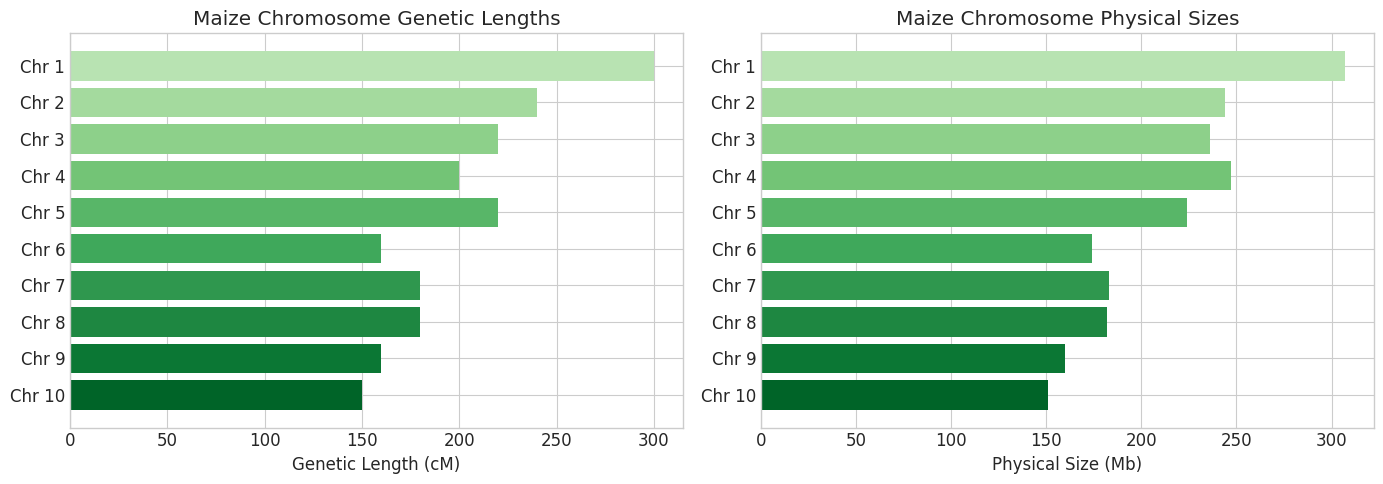

In [6]:
# Visualize chromosome lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genetic length
colors = plt.cm.Greens(np.linspace(0.3, 0.9, 10))
axes[0].barh(df_chromosomes['Chromosome'], df_chromosomes['Genetic_Length_cM'], color=colors)
axes[0].set_xlabel('Genetic Length (cM)')
axes[0].set_title('Maize Chromosome Genetic Lengths')
axes[0].invert_yaxis()

# Physical size
axes[1].barh(df_chromosomes['Chromosome'], df_chromosomes['Physical_Size_Mb'], color=colors)
axes[1].set_xlabel('Physical Size (Mb)')
axes[1].set_title('Maize Chromosome Physical Sizes')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Key Genetic Parameters for Calculations

The following parameters are critical for accurate population size calculations:

In [7]:
# Define maize-specific constants
MAIZE_CHROMOSOMES = 10
DEFAULT_MAP_LENGTH = 1650  # cM (typical value, can range from 1500-1800)

def get_effective_segments(map_length_cM):
    """
    Calculate the effective number of independently segregating chromosome segments.
    
    Formula: L = (map_length / 100) + n_chromosomes
    
    This accounts for:
    - Crossover events (approximately 1 per 100 cM)
    - Independent assortment of chromosomes
    """
    return (map_length_cM / 100) + MAIZE_CHROMOSOMES

L = get_effective_segments(DEFAULT_MAP_LENGTH)

print("Maize Genetic Parameters")
print("=" * 50)
print(f"Number of chromosomes (2n = 20):     {MAIZE_CHROMOSOMES}")
print(f"Total genetic map length:            ~{DEFAULT_MAP_LENGTH} cM")
print(f"Expected crossovers per meiosis:     ~{DEFAULT_MAP_LENGTH/100:.1f}")
print(f"Effective segregating segments (L):  {L:.1f}")
print("\n" + "=" * 50)
print("\nInterpretation:")
print(f"The maize genome behaves as if it has ~{L:.0f} independently")
print("segregating segments during meiosis. This determines the")
print("variance in RP recovery among progeny.")

Maize Genetic Parameters
Number of chromosomes (2n = 20):     10
Total genetic map length:            ~1650 cM
Expected crossovers per meiosis:     ~16.5
Effective segregating segments (L):  26.5


Interpretation:
The maize genome behaves as if it has ~26 independently
segregating segments during meiosis. This determines the
variance in RP recovery among progeny.


<a id='section3'></a>
# Section 3: Expected RP Recovery (Theory)

## Mathematical Derivation

After each backcross, the expected proportion of the recurrent parent (RP) genome increases. Let's derive the formula.

### Starting Point: F1 Generation
- F1 = RP × DP
- F1 genome: 50% RP + 50% DP

### After n Backcrosses
Each backcross to RP replaces, on average, half of the remaining donor genome with RP genome.

**Formula:**
$$R_n = S_0 + (1 - S_0) \times (1 - 0.5^{n+1})$$

Where:
- $R_n$ = Expected RP recovery after n backcrosses
- $S_0$ = Initial genetic similarity between DP and RP (0 to 1)
- $n$ = Number of backcrosses (n=0: F1, n=1: BC1F1, n=2: BC2F1, ...)

**Simplified (when $S_0 = 0$):**
$$R_n = 1 - 0.5^{n+1}$$

So F1 (n=0) = 50%, BC1F1 (n=1) = 75%, BC2F1 (n=2) = 87.5%, etc.

In [ ]:
def expected_recovery(n, S0=0):
    """
    Calculate expected RP genome recovery after n backcrosses.
    
    Parameters:
    -----------
    n : int
        Number of backcross generations
    S0 : float
        Initial genetic similarity between DP and RP (0 to 1)
    
    Returns:
    --------
    float : Expected RP recovery (0 to 1)
    """
    return S0 + (1 - S0) * (1 - 0.5**(n+1))

# Calculate expected recovery for different generations
print("Expected RP Recovery by Generation (S₀ = 0%)")
print("=" * 50)
print(f"{'Generation':<12} {'Formula':<25} {'Recovery':<10}")
print("-" * 50)

generations = ['F1', 'BC1F1', 'BC2F1', 'BC3F1', 'BC4F1', 'BC5F1']
n_values = [0, 1, 2, 3, 4, 5]  # n = number of backcrosses (0 = F1)

for gen, n in zip(generations, n_values):
    rec = expected_recovery(n)
    formula = f"1 - 0.5^{n+1} = 1 - {0.5**(n+1):.4f}"
    print(f"{gen:<12} {formula:<25} {rec*100:.2f}%")

In [ ]:
# Step-by-step calculation example
print("\n" + "=" * 60)
print("STEP-BY-STEP EXAMPLE: BC2F1 with 20% Initial Similarity")
print("=" * 60)

S0 = 0.20  # 20% initial similarity
n = 2      # BC2F1

print(f"\nGiven:")
print(f"  S₀ (initial similarity) = {S0*100:.0f}%")
print(f"  n (backcross generations) = {n}")

print(f"\nFormula: R_n = S₀ + (1 - S₀) × (1 - 0.5^(n+1))")

step1 = 0.5**(n+1)
print(f"\nStep 1: Calculate 0.5^(n+1)")
print(f"        0.5^{n+1} = {step1}")

step2 = 1 - step1
print(f"\nStep 2: Calculate (1 - 0.5^(n+1))")
print(f"        1 - {step1} = {step2}")

step3 = 1 - S0
print(f"\nStep 3: Calculate (1 - S₀)")
print(f"        1 - {S0} = {step3}")

step4 = step3 * step2
print(f"\nStep 4: Calculate (1 - S₀) × (1 - 0.5^(n+1))")
print(f"        {step3} × {step2} = {step4}")

R_n = S0 + step4
print(f"\nStep 5: Calculate R_n = S₀ + result")
print(f"        {S0} + {step4} = {R_n}")

print(f"\n" + "=" * 60)
print(f"RESULT: Expected RP recovery at BC2F1 = {R_n*100:.1f}%")
print("=" * 60)

### Biological Interpretation

> **What does 80% recovery mean?**
>
> At BC2F1 with 20% initial similarity, we expect that **80% of the genome** in our progeny will be identical to the recurrent parent (RP). The remaining **20%** comes from the donor parent (DP), which includes:
> - The target trait locus/loci we want to keep
> - Unwanted "linkage drag" - donor segments flanking the target
> - Random donor segments scattered across the genome

In [ ]:
# Visualize recovery curves for different initial similarities
fig, ax = plt.subplots(figsize=(12, 7))

generations = np.arange(0, 7)
gen_labels = ['F1', 'BC1', 'BC2', 'BC3', 'BC4', 'BC5', 'BC6']
similarities = [0, 0.2, 0.4, 0.6]
colors = ['#1b5e20', '#43a047', '#81c784', '#c8e6c9']

for S0, color in zip(similarities, colors):
    recoveries = [expected_recovery(n, S0) for n in range(0, 7)]
    ax.plot(generations, [r*100 for r in recoveries], 'o-', 
            linewidth=2.5, markersize=8, color=color,
            label=f'Initial similarity = {S0*100:.0f}%')

# Add target line
ax.axhline(y=90, color='#f57c00', linestyle='--', linewidth=2, label='90% target')
ax.axhline(y=95, color='#d32f2f', linestyle=':', linewidth=2, label='95% target')

ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Expected RP Recovery (%)', fontsize=12)
ax.set_title('RP Recovery Progression Across Backcross Generations', fontsize=14)
ax.set_xticks(generations)
ax.set_xticklabels(gen_labels)
ax.set_ylim(45, 100)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id='section4'></a>
# Section 4: Variance of RP Recovery

## Why Does Recovery Vary Between Individuals?

The expected recovery formula gives us the **average** across a population. However, individual plants will vary around this mean due to the **stochastic nature of recombination**.

- Some individuals will have **more favorable recombination** (higher recovery)
- Some will have **less favorable recombination** (lower recovery)

This variation is what allows us to **select** individuals with above-average recovery!

## Variance Formula

Based on Hospital et al. (1992) and Visscher et al. (1996):

$$Var(R_n) \approx \frac{(1 - S_0)^2 \times 0.5^{2(n+1)} \times (1 - 0.5^{n+1})^2}{L}$$

Where:
- $L$ = Effective number of independently segregating segments
- For maize: $L = \frac{map\_length\_cM}{100} + n_{chromosomes} \approx 26.5$

In [ ]:
def recovery_variance(n, S0, L):
    """
    Calculate variance of RP recovery after n backcrosses.
    
    Parameters:
    -----------
    n : int
        Number of backcross generations
    S0 : float
        Initial genetic similarity (0 to 1)
    L : float
        Effective number of segregating segments
    
    Returns:
    --------
    float : Variance of RP recovery
    """
    term1 = (1 - S0)**2
    term2 = 0.5**(2*(n+1))
    term3 = (1 - 0.5**(n+1))**2
    return (term1 * term2 * term3) / L

def recovery_std(n, S0, L):
    """Calculate standard deviation of RP recovery."""
    return np.sqrt(recovery_variance(n, S0, L))

In [ ]:
# Step-by-step variance calculation for BC1F1 in maize
print("=" * 60)
print("VARIANCE CALCULATION: BC1F1 in Maize (S₀ = 0%)")
print("=" * 60)

n = 1
S0 = 0.0
L = get_effective_segments(DEFAULT_MAP_LENGTH)

print(f"\nGiven:")
print(f"  n = {n} (BC1F1)")
print(f"  S₀ = {S0}")
print(f"  L = {L:.1f} (maize effective segments)")

print(f"\nFormula: Var(R_n) = [(1-S₀)² × 0.5^(2(n+1)) × (1-0.5^(n+1))²] / L")

term1 = (1 - S0)**2
print(f"\nStep 1: (1 - S₀)² = (1 - {S0})² = {term1}")

term2 = 0.5**(2*(n+1))
print(f"\nStep 2: 0.5^(2(n+1)) = 0.5^{2*(n+1)} = {term2}")

term3 = (1 - 0.5**(n+1))**2
print(f"\nStep 3: (1 - 0.5^(n+1))² = (1 - {0.5**(n+1):.4f})² = {term3}")

numerator = term1 * term2 * term3
print(f"\nStep 4: Numerator = {term1} × {term2} × {term3} = {numerator}")

variance = numerator / L
std = np.sqrt(variance)
print(f"\nStep 5: Variance = {numerator} / {L:.1f} = {variance:.6f}")
print(f"\nStep 6: Std Dev = √{variance:.6f} = {std:.4f}")

print(f"\n" + "=" * 60)
print(f"RESULT: σ = {std*100:.2f}%")
print("=" * 60)

### Interpretation: What Does σ = 4.9% Mean?

> In a BC1F1 population:
> - **Expected recovery**: 75%
> - **Standard deviation**: ~4.9%
>
> This means:
> - ~68% of individuals will have recovery between **70.1% and 79.9%** (±1σ)
> - ~95% of individuals will have recovery between **65.2% and 84.8%** (±2σ)
> - ~5% of individuals will have recovery **above 83%** (top performers we want to select!)

In [ ]:
# Visualize the distribution of recovery in a BC1F1 population
n = 1
S0 = 0.0
L = get_effective_segments(DEFAULT_MAP_LENGTH)

mean_recovery = expected_recovery(n, S0)
std_recovery = recovery_std(n, S0, L)

# Generate distribution
x = np.linspace(mean_recovery - 4*std_recovery, mean_recovery + 4*std_recovery, 1000)
y = stats.norm.pdf(x, mean_recovery, std_recovery)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot distribution
ax.plot(x*100, y, 'b-', linewidth=2, label='Recovery distribution')
ax.fill_between(x*100, y, alpha=0.3)

# Mark mean and standard deviations
ax.axvline(mean_recovery*100, color='green', linewidth=2, linestyle='-', label=f'Mean = {mean_recovery*100:.1f}%')
ax.axvline((mean_recovery + std_recovery)*100, color='orange', linewidth=1.5, linestyle='--', label=f'+1σ = {(mean_recovery+std_recovery)*100:.1f}%')
ax.axvline((mean_recovery - std_recovery)*100, color='orange', linewidth=1.5, linestyle='--', label=f'-1σ = {(mean_recovery-std_recovery)*100:.1f}%')
ax.axvline((mean_recovery + 2*std_recovery)*100, color='red', linewidth=1.5, linestyle=':', label=f'+2σ = {(mean_recovery+2*std_recovery)*100:.1f}%')

# Shade the top 5%
top_5_threshold = mean_recovery + 1.645 * std_recovery
x_top = x[x >= top_5_threshold]
y_top = stats.norm.pdf(x_top, mean_recovery, std_recovery)
ax.fill_between(x_top*100, y_top, alpha=0.5, color='green', label=f'Top 5% (>{top_5_threshold*100:.1f}%)')

ax.set_xlabel('RP Recovery (%)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Distribution of RP Recovery in BC1F1 Population (Maize)', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTo select individuals in the top 5% (recovery > {top_5_threshold*100:.1f}%),")
print(f"you need a large enough population to find these rare individuals.")

<a id='section5'></a>
# Section 5: Population Size for Backcross Generations (BCnF1)

## Goal: Find Rare High-Recovery Individuals

In backcross generations, we perform **background selection** - selecting individuals with the highest RP genome recovery while maintaining the target trait(s).

## The Question We're Answering

> "How many BC1F1 plants do I need to grow to have a 95% chance of finding at least one plant with ≥X% RP recovery?"

## Mathematical Approach

1. Calculate the probability that a single individual exceeds the target recovery
2. Use the binomial probability to find the required population size

In [ ]:
def population_size_BCnF1(target_recovery, n, S0, L, confidence):
    """
    Calculate required population size for backcross generation.
    
    Parameters:
    -----------
    target_recovery : float
        Desired RP recovery (0 to 1)
    n : int
        Backcross generation number
    S0 : float
        Initial genetic similarity (0 to 1)
    L : float
        Effective segregating segments
    confidence : float
        Desired confidence level (e.g., 0.95)
    
    Returns:
    --------
    int : Required population size
    """
    mean = expected_recovery(n, S0)
    std = recovery_std(n, S0, L)
    
    if std == 0 or target_recovery <= mean:
        return 1
    
    # Calculate z-score
    z = (target_recovery - mean) / std
    
    # Probability of exceeding target
    p_above = 1 - stats.norm.cdf(z)
    
    if p_above <= 0:
        return 10000  # Cap at reasonable value
    if p_above >= 1:
        return 1
    
    # Required population: P(at least 1 success) >= confidence
    # 1 - (1 - p)^N >= confidence
    # (1 - p)^N <= 1 - confidence
    # N >= log(1 - confidence) / log(1 - p)
    N = np.log(1 - confidence) / np.log(1 - p_above)
    
    return max(1, int(np.ceil(N)))

In [ ]:
# Step-by-step example
print("=" * 70)
print("POPULATION SIZE CALCULATION: BC1F1 Background Selection")
print("=" * 70)

# Parameters
n = 1
S0 = 0.0
L = get_effective_segments(DEFAULT_MAP_LENGTH)
target = 0.85  # Want to find individuals with ≥85% recovery
confidence = 0.95

print(f"\nGoal: Find at least one BC1F1 plant with ≥{target*100:.0f}% RP recovery")
print(f"      with {confidence*100:.0f}% confidence")

print(f"\nGiven:")
print(f"  Generation: BC1F1 (n = {n})")
print(f"  Initial similarity: {S0*100:.0f}%")
print(f"  Effective segments (L): {L:.1f}")
print(f"  Target recovery: {target*100:.0f}%")
print(f"  Confidence level: {confidence*100:.0f}%")

# Step 1: Calculate mean and std
mean = expected_recovery(n, S0)
std = recovery_std(n, S0, L)
print(f"\nStep 1: Calculate distribution parameters")
print(f"  Mean recovery = {mean*100:.2f}%")
print(f"  Std deviation = {std*100:.2f}%")

# Step 2: Calculate z-score
z = (target - mean) / std
print(f"\nStep 2: Calculate z-score")
print(f"  z = (target - mean) / std")
print(f"  z = ({target*100:.0f}% - {mean*100:.2f}%) / {std*100:.2f}%")
print(f"  z = {z:.3f}")

# Step 3: Find probability above target
p_above = 1 - stats.norm.cdf(z)
print(f"\nStep 3: Find P(recovery ≥ target)")
print(f"  P(Z ≥ {z:.3f}) = 1 - Φ({z:.3f})")
print(f"  P(above target) = {p_above:.4f} = {p_above*100:.2f}%")

# Step 4: Calculate required population
N = np.log(1 - confidence) / np.log(1 - p_above)
print(f"\nStep 4: Calculate required population size")
print(f"  Formula: N = ln(1 - confidence) / ln(1 - p_above)")
print(f"  N = ln(1 - {confidence}) / ln(1 - {p_above:.4f})")
print(f"  N = ln({1-confidence}) / ln({1-p_above:.4f})")
print(f"  N = {np.log(1-confidence):.4f} / {np.log(1-p_above):.6f}")
print(f"  N = {N:.1f}")

N_final = int(np.ceil(N))
print(f"\n" + "=" * 70)
print(f"RESULT: You need {N_final} BC1F1 plants")
print(f"        to have 95% confidence of finding at least one")
print(f"        with ≥85% RP recovery.")
print("=" * 70)

### Interpretation

> **What this means for the breeder:**
>
> If you grow **142 BC1F1 plants** and genotype them all with genome-wide markers:
> - You have a **95% probability** of finding at least one plant with ≥85% RP recovery
> - On average, you'd expect to find about **3 plants** (142 × 2.1%) meeting this criterion
> - The best plant might have even higher recovery (approaching 90%)

<a id='section6'></a>
# Section 6: Population Size for Selfing Generations (BCnF2)

## Goal: Fix All Traits Homozygous

In the selfing generation (F2), we perform **foreground selection** - identifying individuals that are **homozygous** for all introgressed traits.

## The Challenge: Exponential Decrease in Probability

When we self a heterozygous plant (Aa), the offspring segregate:
- 25% AA (homozygous for desired allele) ✓
- 50% Aa (heterozygous)
- 25% aa (homozygous for undesired allele)

For **t independent traits**, the probability of being homozygous for ALL traits:

$$P_{fixed} = (0.25)^t$$

In [ ]:
def population_size_BCnF2(num_traits, confidence):
    """
    Calculate required population size for selfing generation to fix all traits.
    
    Parameters:
    -----------
    num_traits : int
        Number of independent traits to fix
    confidence : float
        Desired confidence level (e.g., 0.95)
    
    Returns:
    --------
    int : Required population size
    """
    p_fixed = 0.25 ** num_traits
    N = np.log(1 - confidence) / np.log(1 - p_fixed)
    return max(1, int(np.ceil(N)))

In [ ]:
# Step-by-step example for 3 traits
print("=" * 70)
print("POPULATION SIZE CALCULATION: BCnF2 Trait Fixation")
print("=" * 70)

t = 3  # Number of traits
confidence = 0.95

print(f"\nGoal: Find at least one plant homozygous for all {t} traits")
print(f"      with {confidence*100:.0f}% confidence")

print(f"\nStep 1: Calculate probability of fixation for {t} traits")
p_fixed = 0.25 ** t
print(f"  P_fixed = (0.25)^{t}")
print(f"  P_fixed = {p_fixed:.6f}")
print(f"  P_fixed = 1 in {1/p_fixed:.0f} plants")

print(f"\nStep 2: Calculate required population size")
print(f"  Formula: N = ln(1 - confidence) / ln(1 - P_fixed)")
N = np.log(1 - confidence) / np.log(1 - p_fixed)
print(f"  N = ln({1-confidence}) / ln({1-p_fixed:.6f})")
print(f"  N = {np.log(1-confidence):.4f} / {np.log(1-p_fixed):.6f}")
print(f"  N = {N:.1f}")

N_final = int(np.ceil(N))
print(f"\n" + "=" * 70)
print(f"RESULT: You need {N_final} F2 plants")
print(f"        to have 95% confidence of finding at least one")
print(f"        homozygous for all {t} traits.")
print("=" * 70)

In [ ]:
# Table of population sizes for different numbers of traits
print("\nPopulation Size Required for Trait Fixation (95% Confidence)")
print("=" * 65)
print(f"{'Traits':<10} {'P(fixed)':<15} {'1 in X':<12} {'Population':<15}")
print("-" * 65)

for t in range(1, 11):
    p = 0.25 ** t
    N = population_size_BCnF2(t, 0.95)
    print(f"{t:<10} {p:<15.6f} {1/p:<12.0f} {N:<15,}")

print("=" * 65)

In [ ]:
# Visualize the exponential growth
traits = np.arange(1, 11)
populations = [population_size_BCnF2(t, 0.95) for t in traits]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].bar(traits, populations, color='#2e7d32', edgecolor='white')
axes[0].set_xlabel('Number of Traits', fontsize=12)
axes[0].set_ylabel('Required Population Size', fontsize=12)
axes[0].set_title('F2 Population Size (Linear Scale)', fontsize=14)
axes[0].set_xticks(traits)

# Log scale
axes[1].bar(traits, populations, color='#1565c0', edgecolor='white')
axes[1].set_xlabel('Number of Traits', fontsize=12)
axes[1].set_ylabel('Required Population Size (log scale)', fontsize=12)
axes[1].set_title('F2 Population Size (Log Scale)', fontsize=14)
axes[1].set_yscale('log')
axes[1].set_xticks(traits)

# Add value labels
for ax in axes:
    for i, (t, p) in enumerate(zip(traits, populations)):
        if p < 10000:
            ax.text(t, p, f'{p:,}', ha='center', va='bottom', fontsize=8)
        else:
            ax.text(t, p, f'{p/1000:.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n⚠️  KEY INSIGHT: Population size grows EXPONENTIALLY with number of traits!")
print("    Each additional trait multiplies the required population by ~4x.")

<a id='section7'></a>
# Section 7: Minimum Backcross Generations

## How Many Backcrosses to Reach Target Recovery?

We need to find the minimum number of backcross generations (n) such that the expected recovery meets or exceeds our target.

**Solving for n:**

$$R_n = S_0 + (1 - S_0) \times (1 - 0.5^{n+1}) \geq R_{target}$$

$$n \geq \log_2\left(\frac{1 - S_0}{1 - R_{target}}\right) - 1$$

In [ ]:
def min_backcross_generations(target_recovery, S0):
    """
    Calculate minimum backcross generations to reach target recovery.
    
    Parameters:
    -----------
    target_recovery : float
        Target RP recovery (0 to 1)
    S0 : float
        Initial genetic similarity (0 to 1)
    
    Returns:
    --------
    int : Minimum number of backcross generations
    """
    if target_recovery <= S0:
        return 0
    
    ratio = (1 - target_recovery) / (1 - S0)
    if ratio <= 0:
        return 10  # Cap at reasonable value
    
    # R_n = 1 - 0.5^(n+1) >= target => n >= log2(1/ratio) - 1
    n = np.log(ratio) / np.log(0.5) - 1
    return max(0, int(np.ceil(n)))

In [ ]:
# Examples
print("Minimum Backcross Generations to Reach Target Recovery")
print("=" * 60)

targets = [0.90, 0.95, 0.99]
similarities = [0, 0.2, 0.4, 0.6]

print(f"\n{'Target':<10}", end="")
for s in similarities:
    print(f"S₀={s*100:.0f}%{'':<5}", end="")
print()
print("-" * 60)

for target in targets:
    print(f"{target*100:.0f}%{'':<6}", end="")
    for s in similarities:
        n = min_backcross_generations(target, s)
        print(f"BC{n}{'':<9}", end="")
    print()

print("\n" + "=" * 60)
print("\nInterpretation:")
print("- Higher initial similarity → Fewer backcrosses needed")
print("- Higher target recovery → More backcrosses needed")

In [ ]:
# Visualize the trade-off
fig, ax = plt.subplots(figsize=(10, 6))

similarities = np.arange(0, 0.75, 0.05)
targets = [0.90, 0.93, 0.95, 0.97]
colors = ['#1b5e20', '#43a047', '#81c784', '#c8e6c9']

for target, color in zip(targets, colors):
    generations = [min_backcross_generations(target, s) for s in similarities]
    ax.plot(similarities*100, generations, 'o-', color=color, 
            linewidth=2, markersize=6, label=f'Target = {target*100:.0f}%')

ax.set_xlabel('Initial Genetic Similarity (%)', fontsize=12)
ax.set_ylabel('Minimum Backcross Generations', fontsize=12)
ax.set_title('Backcross Generations Required vs. Initial Similarity', fontsize=14)
ax.legend(loc='upper right')
ax.set_yticks(range(1, 8))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7b: The Population Size vs. Generations Trade-off

### Key Insight: Larger Populations Can Reduce Generations Needed

An important concept that is often overlooked: **with a larger population size, you can select rare individuals with higher-than-expected recovery**, potentially allowing you to skip backcross generations and save time.

This is because RP recovery follows a **distribution** around the expected mean. With more plants:
- You sample more of the distribution
- You can find individuals in the upper tail (favorable recombination)
- These individuals may already meet your target recovery

### The Trade-off

| Strategy | Population Size | Generations | Time | Resources |
|----------|-----------------|-------------|------|----------|
| Traditional | Small (~50/gen) | More (4-5 BC) | Longer | Lower per gen |
| Accelerated | Large (~500/gen) | Fewer (2-3 BC) | Shorter | Higher per gen |

In [ ]:
def achievable_recovery_with_population(n, S0, L, population_size, selection_pct):
    """
    Calculate the achievable recovery when selecting the top X% of a population.
    
    With a larger population, you can select more stringently and achieve
    higher recovery than the population mean.
    
    Parameters:
    -----------
    n : int - Backcross generation
    S0 : float - Initial similarity (0-1)
    L : float - Effective segments
    population_size : int - Number of plants grown
    selection_pct : float - Percentage of plants selected (e.g., 5 for top 5%)
    
    Returns:
    --------
    float : Expected recovery of selected individuals
    """
    mean = expected_recovery(n, S0)
    std = recovery_std(n, S0, L)
    
    if std == 0:
        return mean
    
    # Selection intensity: select top X%
    i = selection_pct / 100
    
    # Truncation point (z-score for top X%)
    z = stats.norm.ppf(1 - i)
    
    # Selection differential: mean of truncated normal
    # For truncated normal, E[X | X > z] = mean + std * (pdf(z) / (1-cdf(z)))
    pdf_z = stats.norm.pdf(z)
    selection_differential = pdf_z / i
    
    # Achievable recovery
    achievable = mean + std * selection_differential
    
    return min(achievable, 1.0)  # Cap at 100%

# Example: Compare achievable recovery with different population sizes
print("Achievable Recovery with Different Population Sizes")
print("(Selecting top 5% of each population)")
print("=" * 60)

n = 1  # BC1F1
S0 = 0.0
L = get_effective_segments(DEFAULT_MAP_LENGTH)
selection_pct = 5  # Top 5%

mean_recovery = expected_recovery(n, S0)
print(f"\nBC1F1 Expected (mean) recovery: {mean_recovery*100:.1f}%")
print(f"\nWith top {selection_pct}% selection:")
print(f"{'Population':<15} {'Achievable Recovery':<20} {'Gain over Mean':<15}")
print("-" * 50)

for pop in [50, 100, 200, 500, 1000]:
    achievable = achievable_recovery_with_population(n, S0, L, pop, selection_pct)
    gain = achievable - mean_recovery
    print(f"{pop:<15} {achievable*100:.1f}%{'':<14} +{gain*100:.1f}%")

In [ ]:
# Visualize the trade-off: Population size vs. Generations needed
fig, ax = plt.subplots(figsize=(12, 7))

S0 = 0.0
L = get_effective_segments(DEFAULT_MAP_LENGTH)
selection_pct = 5

populations = [25, 50, 100, 200, 300, 500, 750, 1000, 1500, 2000]
target_recoveries = [0.85, 0.88, 0.90, 0.93, 0.95]
colors = ['#c8e6c9', '#81c784', '#4caf50', '#388e3c', '#1b5e20']

for target, color in zip(target_recoveries, colors):
    generations_needed = []
    for pop in populations:
        # Find minimum generations to reach target with this population
        gen_needed = 7  # Max (not achievable)
        for n in range(1, 7):
            achievable = achievable_recovery_with_population(n, S0, L, pop, selection_pct)
            if achievable >= target:
                gen_needed = n
                break
        generations_needed.append(gen_needed if gen_needed <= 6 else np.nan)
    
    ax.plot(populations, generations_needed, 'o-', color=color, 
            linewidth=2.5, markersize=8, label=f'{target*100:.0f}% target')

ax.set_xlabel('Population Size per Generation', fontsize=12)
ax.set_ylabel('Backcross Generations Needed', fontsize=12)
ax.set_title('Trade-off: Larger Populations Enable Fewer Generations', fontsize=14)
ax.set_xscale('log')
ax.set_xticks([50, 100, 200, 500, 1000, 2000])
ax.set_xticklabels(['50', '100', '200', '500', '1K', '2K'])
ax.set_yticks([1, 2, 3, 4, 5, 6])
ax.set_ylim(0.5, 6.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate('More time\n(more generations)', xy=(50, 5), fontsize=10, color='#757575')
ax.annotate('Less time\n(fewer generations)', xy=(1000, 2), fontsize=10, color='#757575')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY INSIGHT")
print("=" * 60)
print("\nWith 200 plants/generation (selecting top 5%), you can reach")
print("90% recovery in BC2 instead of BC4 - saving 2 generations!")
print("\nThis is the power of combining larger populations with")
print("stringent selection for background recovery.")

### Interpretation: When to Use Larger Populations

> **Use larger populations when:**
> - Time is more limiting than resources (e.g., need variety quickly)
> - You have high-throughput genotyping capacity
> - The trait is difficult to phenotype (rely on markers)
>
> **Use smaller populations when:**
> - Resources are limited (greenhouse space, genotyping budget)
> - Time is not critical
> - You're introgressing many traits (F2 population is the bottleneck anyway)

<a id='section8'></a>
# Section 8: Complete Workflow Example

Let's work through a complete example of designing a trait introgression program.

In [ ]:
def calculate_breeding_scheme(num_traits, target_recovery, initial_similarity, confidence, map_length):
    """
    Calculate complete breeding scheme for trait introgression.
    
    Returns a dictionary with all generation details.
    """
    S0 = initial_similarity / 100
    target = target_recovery / 100
    L = get_effective_segments(map_length)
    
    min_gen = min_backcross_generations(target, S0)
    generations = []
    total_population = 0
    
    # Backcross generations
    for n in range(1, min_gen + 1):
        exp_rec = expected_recovery(n, S0)
        std = recovery_std(n, S0, L)
        
        # Selection target: above average for intermediate, target for final
        selection_target = exp_rec + std if n < min_gen else target
        pop_size = population_size_BCnF1(selection_target, n, S0, L, confidence)
        
        generations.append({
            'name': f'BC{n}F1',
            'type': 'backcross',
            'goal': 'Background selection',
            'expected_recovery': exp_rec,
            'std_dev': std,
            'population': pop_size
        })
        total_population += pop_size
    
    # Final selfing generation
    f2_pop = population_size_BCnF2(num_traits, confidence)
    generations.append({
        'name': f'BC{min_gen}F2',
        'type': 'selfing',
        'goal': 'Foreground selection (fix traits)',
        'expected_recovery': expected_recovery(min_gen, S0),
        'std_dev': 0,
        'population': f2_pop
    })
    total_population += f2_pop
    
    return {
        'generations': generations,
        'total_population': total_population,
        'min_backcrosses': min_gen,
        'f2_population': f2_pop
    }

In [ ]:
# Complete example
print("=" * 70)
print("COMPLETE BREEDING SCHEME EXAMPLE")
print("=" * 70)

# Scenario: Introgress 2 drought tolerance QTLs into elite inbred
params = {
    'num_traits': 2,
    'target_recovery': 90,  # %
    'initial_similarity': 15,  # %
    'confidence': 0.95,
    'map_length': 1650  # cM
}

print("\nSCENARIO: Introgress 2 drought tolerance QTLs into elite inbred")
print("\nParameters:")
print(f"  Number of traits: {params['num_traits']}")
print(f"  Target RP recovery: {params['target_recovery']}%")
print(f"  Initial similarity: {params['initial_similarity']}%")
print(f"  Confidence level: {params['confidence']*100:.0f}%")
print(f"  Genetic map length: {params['map_length']} cM")

results = calculate_breeding_scheme(**params)

print("\n" + "-" * 70)
print("BREEDING SCHEME:")
print("-" * 70)
print(f"{'Generation':<12} {'Type':<12} {'Goal':<25} {'Recovery':<12} {'Population':<12}")
print("-" * 70)

for gen in results['generations']:
    print(f"{gen['name']:<12} {gen['type']:<12} {gen['goal']:<25} "
          f"{gen['expected_recovery']*100:.1f}%{'':<6} {gen['population']:,}")

print("-" * 70)
print(f"{'TOTAL':<12} {'':<12} {'':<25} {'':<12} {results['total_population']:,}")
print("=" * 70)

print("\nSUMMARY:")
print(f"  • Backcross generations required: {results['min_backcrosses']}")
print(f"  • Total plants to grow: {results['total_population']:,}")
print(f"  • Final F2 population: {results['f2_population']:,}")

<a id='section9'></a>
# Section 9: Interactive Parameter Explorer

Use the sliders below to explore how different parameters affect the breeding scheme.

In [ ]:
def interactive_calculator(num_traits, target_recovery, initial_similarity, confidence):
    """
    Interactive function for parameter exploration.
    """
    results = calculate_breeding_scheme(
        num_traits=num_traits,
        target_recovery=target_recovery,
        initial_similarity=initial_similarity,
        confidence=confidence/100,
        map_length=1650
    )
    
    # Create visualization
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('RP Recovery Progression', 'Population Size by Generation'),
        specs=[[{"type": "scatter"}, {"type": "bar"}]]
    )
    
    # Recovery progression
    gen_names = [g['name'] for g in results['generations']]
    recoveries = [g['expected_recovery']*100 for g in results['generations']]
    
    fig.add_trace(
        go.Scatter(x=gen_names, y=recoveries, mode='lines+markers',
                   name='Expected Recovery', line=dict(color='#2e7d32', width=3),
                   marker=dict(size=10)),
        row=1, col=1
    )
    
    # Target line
    fig.add_hline(y=target_recovery, line_dash="dash", line_color="#f57c00",
                  annotation_text=f"Target: {target_recovery}%", row=1, col=1)
    
    # Population sizes
    populations = [g['population'] for g in results['generations']]
    colors = ['#1565c0' if g['type'] == 'backcross' else '#2e7d32' 
              for g in results['generations']]
    
    fig.add_trace(
        go.Bar(x=gen_names, y=populations, marker_color=colors, name='Population'),
        row=1, col=2
    )
    
    fig.update_layout(
        height=400,
        showlegend=False,
        title_text=f"Breeding Scheme: {num_traits} traits, {target_recovery}% target, {initial_similarity}% similarity"
    )
    fig.update_yaxes(title_text="RP Recovery (%)", row=1, col=1)
    fig.update_yaxes(title_text="Population Size", type="log", row=1, col=2)
    
    fig.show()
    
    print(f"\n📊 Results Summary:")
    print(f"   Backcross generations: {results['min_backcrosses']}")
    print(f"   Total population: {results['total_population']:,}")

# Create interactive widget
interact(
    interactive_calculator,
    num_traits=IntSlider(min=1, max=10, step=1, value=2, description='Traits:'),
    target_recovery=IntSlider(min=80, max=99, step=1, value=90, description='Target %:'),
    initial_similarity=IntSlider(min=0, max=70, step=5, value=0, description='Similarity %:'),
    confidence=IntSlider(min=90, max=99, step=1, value=95, description='Confidence %:')
);

<a id='section10'></a>
# Section 10: Sensitivity Analysis

Which parameters have the biggest impact on population size requirements?

In [ ]:
# Sensitivity analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Effect of number of traits
traits = range(1, 11)
similarities = [0, 20, 40]
for sim in similarities:
    pops = [calculate_breeding_scheme(t, 90, sim, 0.95, 1650)['total_population'] for t in traits]
    axes[0].semilogy(traits, pops, 'o-', label=f'{sim}% similarity', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Traits')
axes[0].set_ylabel('Total Population (log scale)')
axes[0].set_title('Impact of Number of Traits')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Effect of target recovery
recoveries = range(80, 99, 2)
trait_counts = [1, 2, 3, 5]
for t in trait_counts:
    pops = [calculate_breeding_scheme(t, r, 0, 0.95, 1650)['total_population'] for r in recoveries]
    axes[1].semilogy(recoveries, pops, 'o-', label=f'{t} trait{"s" if t>1 else ""}', linewidth=2, markersize=6)
axes[1].set_xlabel('Target Recovery (%)')
axes[1].set_ylabel('Total Population (log scale)')
axes[1].set_title('Impact of Target Recovery')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Effect of initial similarity
similarities = range(0, 71, 10)
for t in trait_counts:
    pops = [calculate_breeding_scheme(t, 90, s, 0.95, 1650)['total_population'] for s in similarities]
    axes[2].semilogy(similarities, pops, 'o-', label=f'{t} trait{"s" if t>1 else ""}', linewidth=2, markersize=6)
axes[2].set_xlabel('Initial Similarity (%)')
axes[2].set_ylabel('Total Population (log scale)')
axes[2].set_title('Impact of Initial Similarity')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("KEY INSIGHTS FROM SENSITIVITY ANALYSIS")
print("=" * 70)
print("\n1. NUMBER OF TRAITS has the LARGEST impact (exponential effect)")
print("   → Each additional trait roughly quadruples the F2 population needed")
print("\n2. INITIAL SIMILARITY has a moderate impact")
print("   → Higher similarity reduces backcross generations needed")
print("   → Can save 1-2 generations if parents share 40-60% genome")
print("\n3. TARGET RECOVERY has a smaller impact")
print("   → Going from 90% to 95% target adds ~1 backcross generation")
print("   → Diminishing returns above 95% target")

<a id='section11'></a>
# Section 11: Assumptions and Limitations

## When Does This Model Work Well?

✅ **Good assumptions:**
- Traits are on different chromosomes (unlinked)
- Marker-assisted selection (MAS) is available
- Recombination rates are relatively uniform
- Large effective population size

## When Does This Model Break Down?

⚠️ **Limitations:**

1. **Linked traits**: If traits are on the same chromosome, the probability calculations change significantly

2. **Linkage drag**: The model doesn't account for donor segments flanking the target locus that are difficult to remove

3. **Non-uniform recombination**: Maize has recombination hotspots and coldspots; the model assumes uniform rates

4. **Selection efficiency**: Real-world selection is not perfect; genotyping errors, sampling, and phenotyping errors reduce efficiency

5. **Germination and survival**: Not all planted seeds will produce genotypable plants

## Practical Adjustments

For real breeding programs, consider:
- Adding 20-30% buffer to population sizes
- Accounting for germination rate (~90-95% for good seed)
- Considering genotyping capacity constraints
- Planning for multiple selection cycles if needed